# Mixture Gaussians
Vamos aplicar o modelo probabilístico **Mixture Gaussians** para achar clusters
$$
    \ln p(X|\mu, \Sigma, \pi) = \sum_{n=1}^N \ln \{ \sum_{k=1}^K \pi_k \mathcal{N}(x_n|\mu_k, \Sigma_k) \}
$$

In [ ]:
import torch
import matplotlib.pyplot as plt
import pandas as pd

import sys
from pathlib import Path

root = Path().resolve().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from classes.mixture_gaussians import MixtureGaussians

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/geyser.csv"
data = pd.read_csv(url)

True
Using GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [2]:
data.head()

,duration,waiting,kind
0,3.600,79,long
1,1.800,54,short
2,3.333,74,long
3,2.283,62,short
4,4.533,85,long


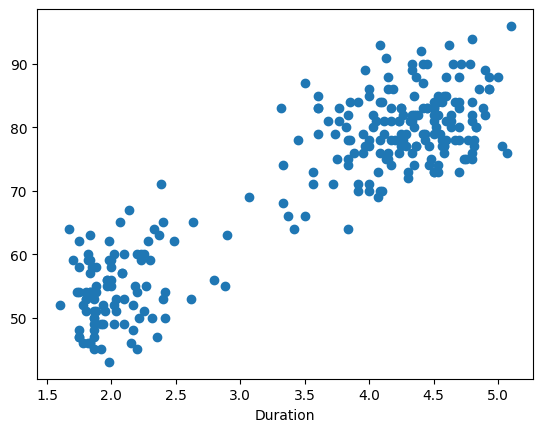

In [3]:
plt.plot(data['duration'], data['waiting'], 'o')
plt.xlabel('Duration')
plt.show()

In [4]:
X = torch.tensor(data.drop(columns=['kind']).values, device=device, dtype=torch.float32)

In [5]:
ks = [1, 2, 3, 4, 5]
models = []

def convergence_criterium(old_params: torch.Tensor, new_params: torch.Tensor) -> bool:
    return torch.norm(new_params - old_params) < 1e-4

for k in ks:
    model = MixtureGaussians(k=k, d=X.shape[1], device=device, convergence_criterium=convergence_criterium)
    model.forward(X)
    models.append(model)

In [7]:
def BIC(model: MixtureGaussians, X: torch.Tensor) -> float:
    """
    Bayesian Information Criterion for model selection.

    Args:
        model (MixtureGaussians): The fitted mixture of Gaussians model.
        X (torch.Tensor): The data used to fit the model.

    Returns:
        float: The BIC score for the model.
    """
    N, D = X.shape
    K = model.k
    log_likelihood = model.log_likelihood(X).item()
    num_params = K * D + K - 1 + K*(D * (D + 1) // 2)  # K means + K-1 mixing coefficients + K covariance matrices
    bic_score = -2 * log_likelihood + num_params * torch.log(torch.tensor(N)).item()
    return bic_score

In [8]:
# Selecting the best model based on BIC
bic_scores = [BIC(model, X) for model in models]
best_k = ks[bic_scores.index(min(bic_scores))]
print(f"Best number of components according to BIC: {best_k}")

Best number of components according to BIC: 2


In [13]:
# Parameters of the best model
best_model = models[ks.index(best_k)]
print(f"Means:\n{best_model.mu}")
print(f"Covariances:\n{best_model.covariances}")
print(f"Mixing Coefficients:\n{best_model.pi}")

Means:
tensor([[ 2.0364, 54.4785],
        [ 4.2897, 79.9681]], device='cuda:0')
Covariances:
tensor([[[ 0.0692,  0.4352],
         [ 0.4352, 33.6973]],

        [[ 0.1700,  0.9406],
         [ 0.9406, 36.0462]]], device='cuda:0')
Mixing Coefficients:
tensor([0.3559, 0.6441], device='cuda:0')


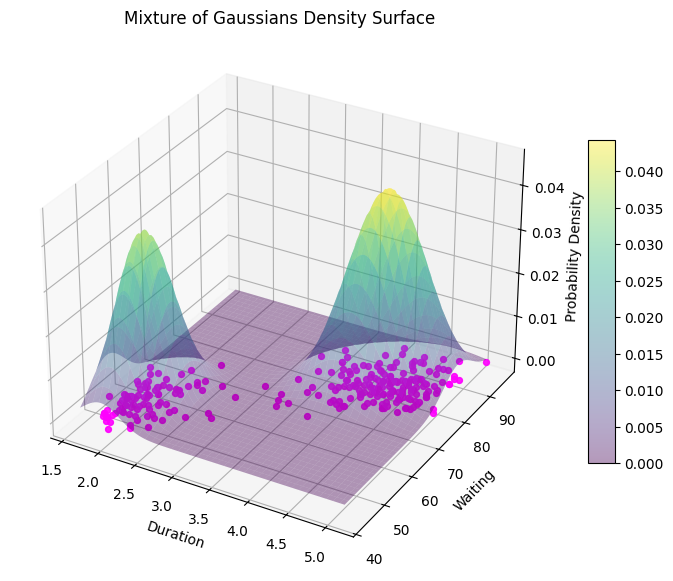

In [18]:
# 3D surface of the mixture density over the feature space
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import cm

# Move params to CPU for plotting
mu = best_model.mu.detach().cpu()
covs = best_model.covariances.detach().cpu()
pis = best_model.pi.detach().cpu()

# Build grid from data range
X_cpu = X.detach().cpu().numpy()
x_min, x_max = X_cpu[:, 0].min(), X_cpu[:, 0].max()
y_min, y_max = X_cpu[:, 1].min(), X_cpu[:, 1].max()
gx = np.linspace(x_min, x_max, 120)
gy = np.linspace(y_min, y_max, 120)
XX, YY = np.meshgrid(gx, gy)
grid = np.column_stack([XX.ravel(), YY.ravel()])

# Compute mixture density on the grid
grid_t = torch.tensor(grid, dtype=torch.float32)
K = best_model.k
D = grid_t.shape[1]
norm_const = (2 * np.pi) ** (D / 2)
dens = torch.zeros(grid_t.shape[0], dtype=torch.float32)

for k in range(K):
    diff = grid_t - mu[k]
    cov = covs[k]
    inv_cov = torch.linalg.inv(cov)
    det_cov = torch.linalg.det(cov)
    exponent = -0.5 * torch.sum((diff @ inv_cov) * diff, dim=1)
    comp = torch.exp(exponent) / (norm_const * torch.sqrt(det_cov))
    dens += pis[k] * comp

ZZ = dens.reshape(XX.shape).numpy()

# Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(XX, YY, ZZ, cmap=cm.viridis, linewidth=0, antialiased=True, alpha=0.4)

# Scatter data points on the horizontal plane (z=0)
z0 = np.zeros_like(X_cpu[:, 0])
ax.scatter(X_cpu[:, 0], X_cpu[:, 1], z0, color='#ff00ff', s=18, alpha=0.9, depthshade=False)

ax.set_xlabel('Duration')
ax.set_ylabel('Waiting')
ax.set_zlabel('Probability Density')
ax.set_title('Mixture of Gaussians Density Surface')
fig.colorbar(surf, shrink=0.6, aspect=12)
plt.show()